# PostgreSQL Benchmark Results Analysis - RAID HDD

This notebook analyzes the results of TPC-C benchmarks conducted on a PostgreSQL database named `raidhdd` across various terminal counts.

## Methodology
- **Base State**: The run with 2 terminals (`results_raidhdd_term2`) was performed first and serves as the baseline for `pg_stat` tables.
- **Deltas**: For each run, statistics are calculated as deltas from the previous run in chronological order.
- **Filtering**: Only the `raidhdd` database is considered.
- **Comparisons**: The 2-terminal run is used for baseline calculation but excluded from terminal count comparisons (1, 10, 20, 30, 40, 50, 60, 70).

In [12]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [13]:
def load_benchmark_data(base_dir):
    results = []
    dirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d)) and 'results_raidhdd_term' in d]
    
    for d in dirs:
        dir_path = os.path.join(base_dir, d)
        files = os.listdir(dir_path)
        
        summary_file = next((f for f in files if f.endswith('.summary.json')), None)
        metrics_file = next((f for f in files if f.endswith('.metrics.json')), None)
        
        if not summary_file or not metrics_file:
            continue
            
        with open(os.path.join(dir_path, summary_file), 'r') as f:
            summary = json.load(f)
        
        with open(os.path.join(dir_path, metrics_file), 'r') as f:
            metrics = json.load(f)
            
        terminals = int(summary.get('terminals', d.split('term')[-1]))
        start_ts = summary.get('Start timestamp (milliseconds)', 0)
        
        results.append({
            'dir': d,
            'terminals': terminals,
            'start_ts': start_ts,
            'summary': summary,
            'metrics': metrics
        })
    
    # Sort by start timestamp to calculate deltas correctly
    results.sort(key=lambda x: x['start_ts'])
    return results

data = load_benchmark_data('data/')
print(f"Loaded {len(data)} benchmark runs.")

Loaded 9 benchmark runs.


In [14]:
def process_stats(data):
    processed = []
    
    for i in range(len(data)):
        curr = data[i]
        prev = data[i-1] if i > 0 else None
        
        res = {
            'terminals': curr['terminals'],
            'throughput': curr['summary']['Throughput (requests/second)'],
            'goodput': curr['summary'].get('Goodput (requests/second)', 0),
            'avg_latency': curr['summary']['Latency Distribution']['Average Latency (microseconds)'] / 1000.0, # ms
            'p95_latency': curr['summary']['Latency Distribution']['95th Percentile Latency (microseconds)'] / 1000.0, # ms
        }
        
        # Database stats for 'raidhdd'
        db_metrics = next((m for m in curr['metrics']['pg_stat_database'] if m['datname'] == 'raidhdd'), {})
        if prev:
            prev_db_metrics = next((m for m in prev['metrics']['pg_stat_database'] if m['datname'] == 'raidhdd'), {})
            res['db_tup_inserted'] = int(db_metrics.get('tup_inserted', 0)) - int(prev_db_metrics.get('tup_inserted', 0))
            res['db_tup_returned'] = int(db_metrics.get('tup_returned', 0)) - int(prev_db_metrics.get('tup_returned', 0))
            res['db_blks_read'] = int(db_metrics.get('blks_read', 0)) - int(prev_db_metrics.get('blks_read', 0))
            res['db_blks_hit'] = int(db_metrics.get('blks_hit', 0)) - int(prev_db_metrics.get('blks_hit', 0))
            res['db_xact_commit'] = int(db_metrics.get('xact_commit', 0)) - int(prev_db_metrics.get('xact_commit', 0))
        else:
            res['db_tup_inserted'] = 0
            
        # Table stats (summed across tables)
        table_stats = [t for t in curr['metrics']['pg_stat_user_tables'] if t['relname'] != 'citations']
        if prev:
            prev_table_stats = {t['relname']: t for t in prev['metrics']['pg_stat_user_tables'] if t['relname'] != 'citations'}
            res['total_tup_ins'] = sum(int(t['n_tup_ins']) - int(prev_table_stats.get(t['relname'], {}).get('n_tup_ins', t['n_tup_ins'])) for t in table_stats)
            res['total_tup_upd'] = sum(int(t['n_tup_upd']) - int(prev_table_stats.get(t['relname'], {}).get('n_tup_upd', t['n_tup_upd'])) for t in table_stats)
            
        processed.append(res)
        
    return pd.DataFrame(processed)

df = process_stats(data)
# Filter out the baseline (term 2) and sort by terminals
df_plot = df[df['terminals'] != 2].sort_values('terminals')
df_plot

,terminals,throughput,goodput,avg_latency,p95_latency,db_tup_inserted,db_tup_returned,db_blks_read,db_blks_hit,db_xact_commit,total_tup_ins,total_tup_upd
1,1,63.229999,68.731665,15.808,45.138,479183,16765088.0,2796894.0,34799894.0,82670.0,478976.0,919515.0
2,10,248.328323,254.015823,40.069,150.893,1773833,56181621.0,29632463.0,102943320.0,305051.0,1773635.0,3365412.0
3,20,345.709984,367.001649,57.711,250.754,2553553,74254219.0,35275887.0,144958723.0,440695.0,2553310.0,4886711.0
4,30,504.743329,536.490829,59.374,270.108,3743491,102274090.0,49784356.0,207364754.0,644081.0,3743268.0,7056940.0
5,40,794.087486,829.268318,50.347,225.299,5789771,124858218.0,63527680.0,300241245.0,995438.0,5789569.0,10990097.0
6,50,1225.058305,1263.710805,40.786,159.830,8804950,178663163.0,85852238.0,453061432.0,1516785.0,8804753.0,16714339.0
7,60,1710.005796,1814.680794,34.924,116.783,12652640,289783891.0,130302300.0,675655823.0,2177976.0,12652419.0,24019795.0
8,70,2161.227495,2297.799161,32.376,109.419,16014062,204037726.0,97758362.0,747118007.0,2757733.0,16013860.0,30494374.0


## Throughput and Goodput Analysis

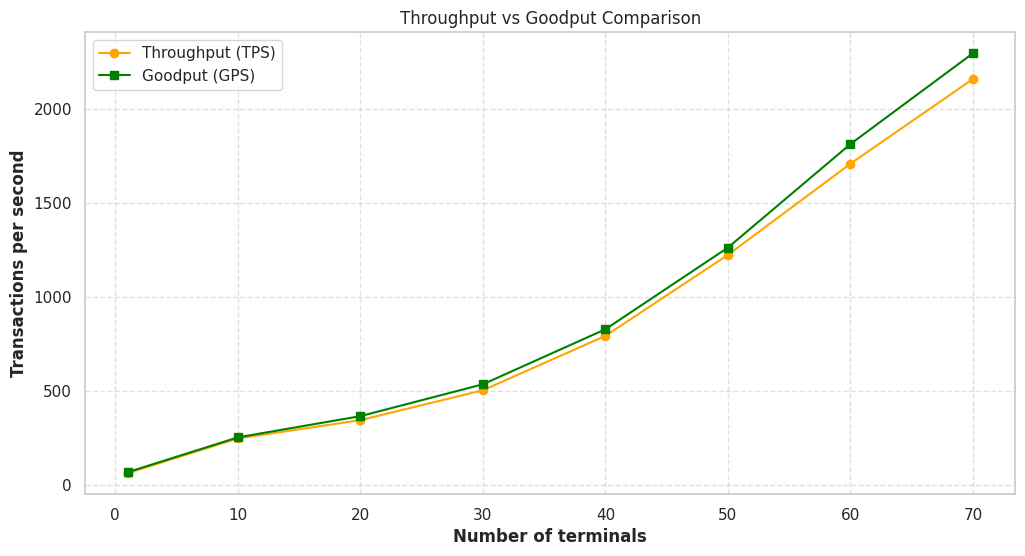

In [15]:
plt.figure(figsize=(12, 6))
plt.grid(True, linestyle='--', alpha=0.6)
plt.plot(df_plot['terminals'], df_plot['throughput'], label='Throughput (TPS)', color='orange', marker='o')
plt.plot(df_plot['terminals'], df_plot['goodput'], label='Goodput (GPS)', color='green', marker='s')
plt.xlabel('Number of terminals', fontsize=12, fontweight='bold')
plt.ylabel('Transactions per second', fontsize=12, fontweight='bold')
plt.title('Throughput vs Goodput Comparison')
plt.legend()
plt.show()

## Latency Distribution (Box Plot)

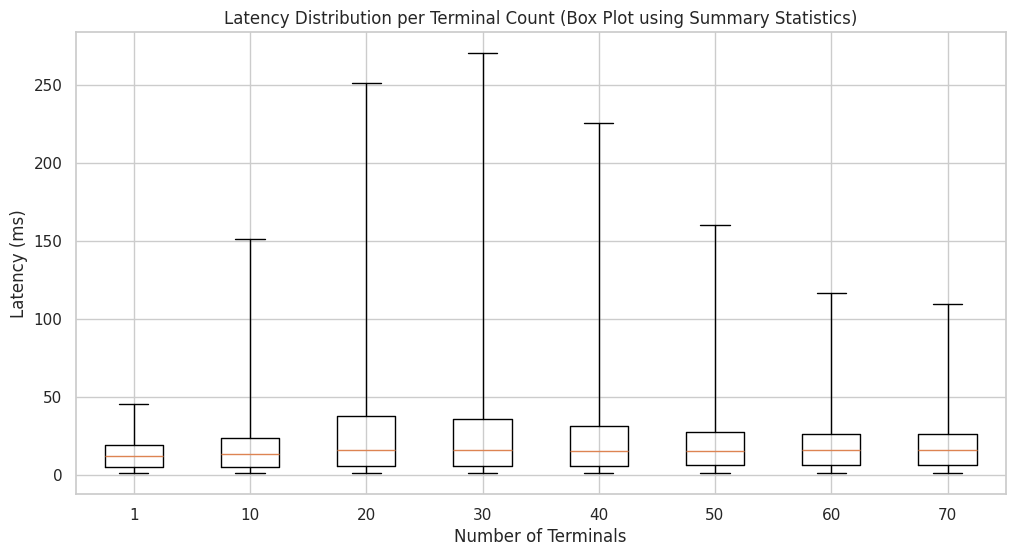

In [16]:
def prepare_boxplot_data(data):
    stats_list = []
    for entry in data:
        if entry['terminals'] == 2:
            continue
        dist = entry['summary']['Latency Distribution']
        # We use precalculated percentiles to build boxplot statistics
        stats_list.append({
            'label': str(entry['terminals']),
            'med': dist['Median Latency (microseconds)'] / 1000.0,
            'q1': dist['25th Percentile Latency (microseconds)'] / 1000.0,
            'q3': dist['75th Percentile Latency (microseconds)'] / 1000.0,
            'whislo': dist['Minimum Latency (microseconds)'] / 1000.0,
            'whishi': dist['95th Percentile Latency (microseconds)'] / 1000.0, # Using P95 for top whisker to avoid outliers scaling
            'fliers': []
        })
    return stats_list

bx_stats = prepare_boxplot_data(data)
bx_stats.sort(key=lambda x: int(x['label']))

fig, ax = plt.subplots(figsize=(12, 6))
ax.bxp(bx_stats, showfliers=False)
ax.set_ylabel('Latency (ms)')
ax.set_xlabel('Number of Terminals')
ax.set_title('Latency Distribution per Terminal Count (Box Plot using Summary Statistics)')
plt.show()

## Throughput and Latency Overview

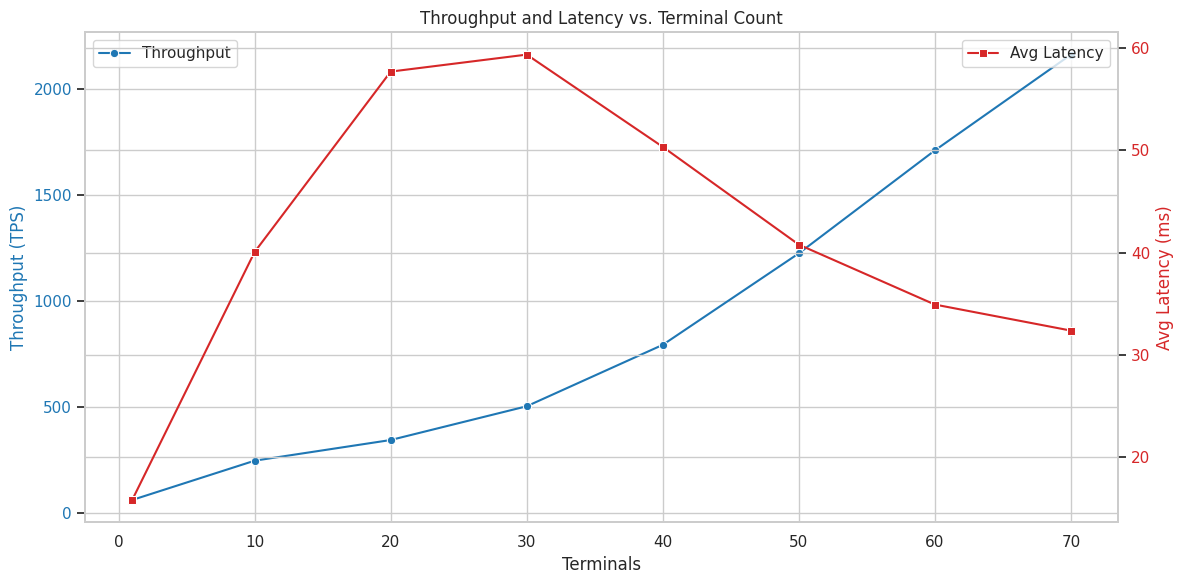

In [17]:
fig, ax1 = plt.subplots()

ax1.set_xlabel('Terminals')
ax1.set_ylabel('Throughput (TPS)', color='tab:blue')
sns.lineplot(data=df_plot, x='terminals', y='throughput', marker='o', ax=ax1, color='tab:blue', label='Throughput')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Avg Latency (ms)', color='tab:red')
sns.lineplot(data=df_plot, x='terminals', y='avg_latency', marker='s', ax=ax2, color='tab:red', label='Avg Latency')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Throughput and Latency vs. Terminal Count')
fig.tight_layout()
plt.show()

## Database Activity (pg_stat_database deltas)

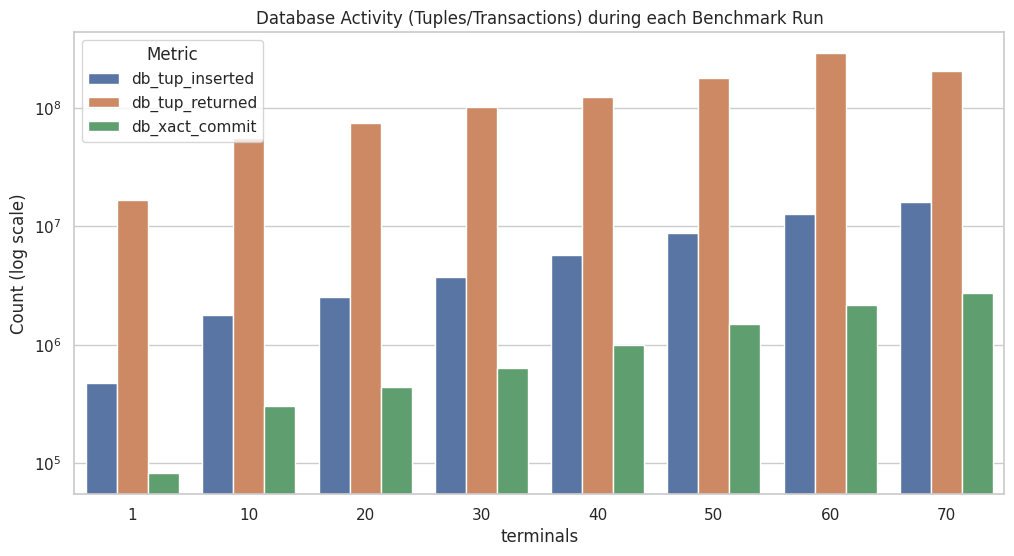

In [18]:
cols = ['db_tup_inserted', 'db_tup_returned', 'db_xact_commit']
df_melted = df_plot.melt(id_vars='terminals', value_vars=cols, var_name='Metric', value_name='Count')
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='terminals', y='Count', hue='Metric')
plt.title('Database Activity (Tuples/Transactions) during each Benchmark Run')
plt.yscale('log')
plt.ylabel('Count (log scale)')
plt.show()

## Block I/O Activity

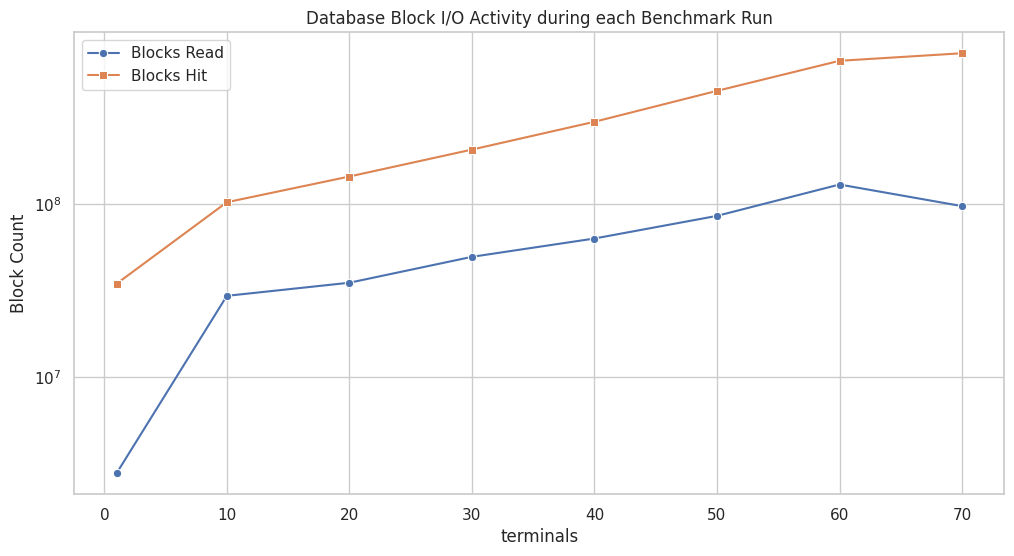

In [19]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x='terminals', y='db_blks_read', marker='o', label='Blocks Read')
sns.lineplot(data=df_plot, x='terminals', y='db_blks_hit', marker='s', label='Blocks Hit')
plt.title('Database Block I/O Activity during each Benchmark Run')
plt.ylabel('Block Count')
plt.yscale('log')
plt.legend()
plt.show()